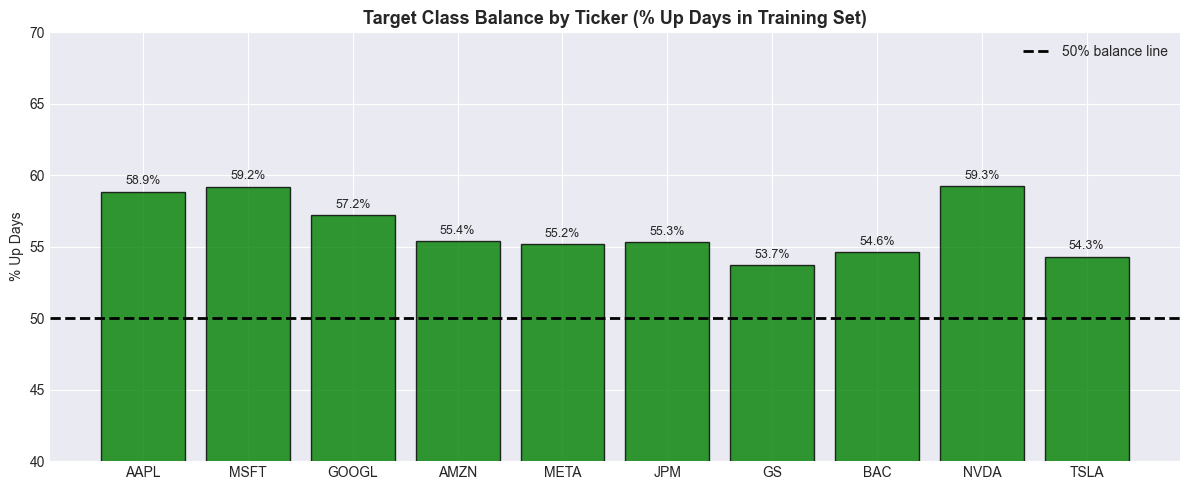

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, warnings

warnings.filterwarnings('ignore')
sys.path.append('../..')
from src.utils.config import TICKERS, PROCESSED_DIR

plt.style.use('seaborn-v0_8-darkgrid')

# Load target data for all tickers
target_data = {}
for ticker in TICKERS:
    y = pd.read_csv(PROCESSED_DIR / f'splits/{ticker}/y_train.csv',
                    index_col=0, parse_dates=True).squeeze()
    target_data[ticker] = y

# Plot class balance per ticker
fig, ax = plt.subplots(figsize=(12, 5))
up_rates = {t: y.mean()*100 for t, y in target_data.items()}
colors   = ['green' if v > 50 else 'red' for v in up_rates.values()]

bars = ax.bar(up_rates.keys(), up_rates.values(),
              color=colors, edgecolor='black', alpha=0.8)

ax.axhline(50, color='black', linestyle='--', linewidth=2,
           label='50% balance line')

ax.set_title('Target Class Balance by Ticker (% Up Days in Training Set)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('% Up Days')
ax.set_ylim(40, 70)
ax.legend()

for bar, (t, v) in zip(bars, up_rates.items()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{v:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../../docs/eda/12_target_balance.png', dpi=150)
plt.show()

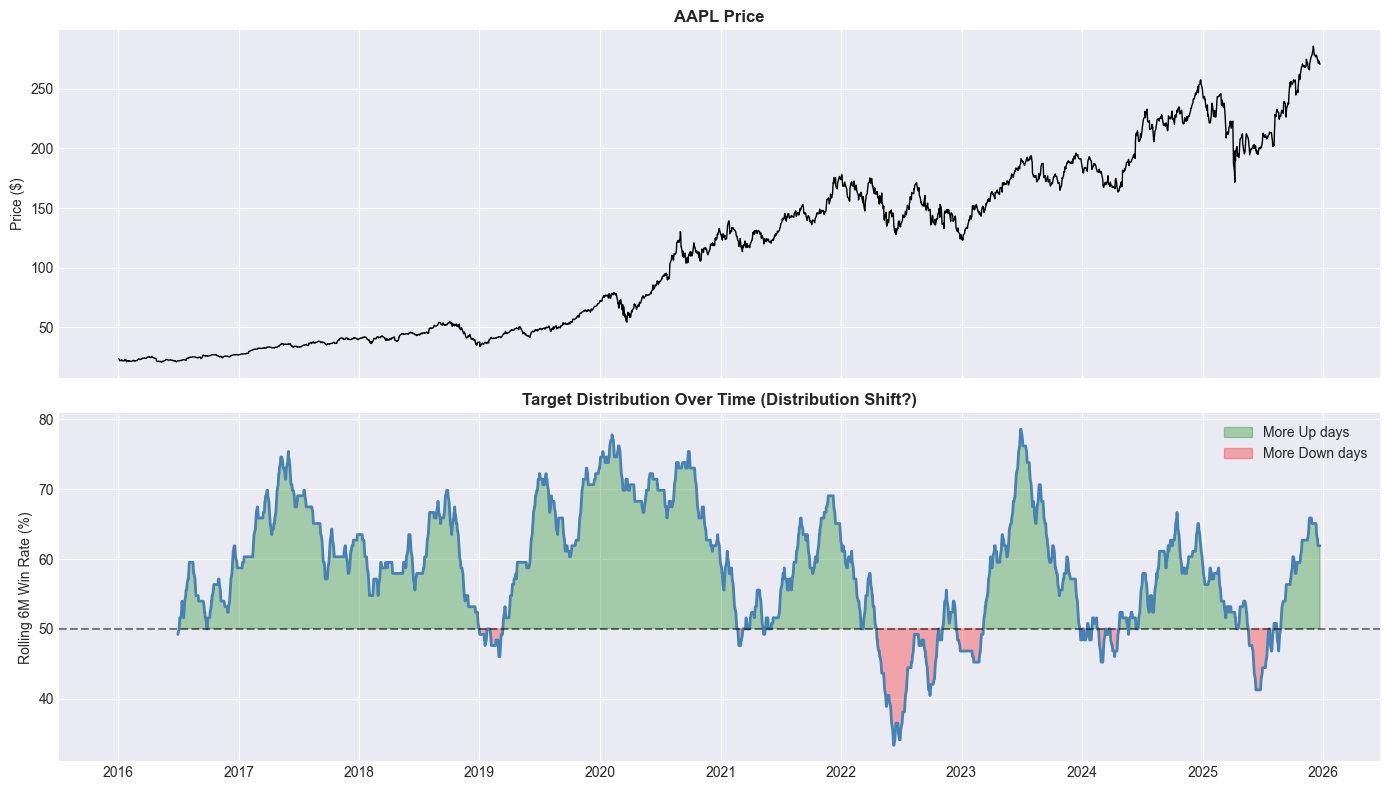

In [2]:
# Load full AAPL feature data with target
aapl = pd.read_csv(PROCESSED_DIR / 'features/AAPL_features.csv',
                   index_col=0, parse_dates=True)
# Rolling 6-month win rate
win_rate = aapl['Target_Direction'].rolling(126).mean() * 100
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
ax1.plot(aapl.index, aapl['Close'], color='black', linewidth=1)
ax1.set_ylabel('Price ($)')
ax1.set_title('AAPL Price', fontweight='bold')
ax2.plot(win_rate.index, win_rate.values,
         color='steelblue', linewidth=2)
ax2.axhline(50, color='black', linestyle='--', alpha=0.5)
ax2.fill_between(win_rate.index, win_rate.values, 50,
                  where=win_rate.values > 50,
                  color='green', alpha=0.3, label='More Up days')
ax2.fill_between(win_rate.index, win_rate.values, 50,
                  where=win_rate.values < 50,
                  color='red', alpha=0.3, label='More Down days')
ax2.set_ylabel('Rolling 6M Win Rate (%)')
ax2.set_title('Target Distribution Over Time (Distribution Shift?)', fontweight='bold')
ax2.legend()
plt.tight_layout()
plt.savefig('../../docs/eda/13_target_distribution_shift.png', dpi=150)
plt.show()

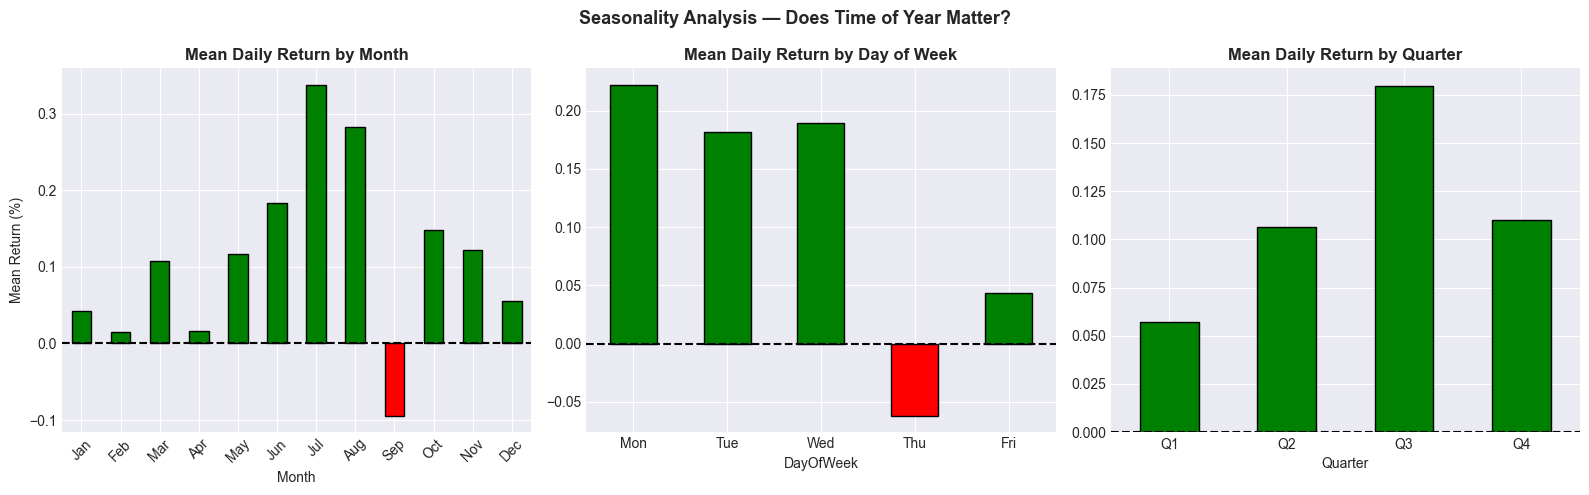

In [3]:
# Does the market have seasonal patterns?
aapl['Month']     = aapl.index.month
aapl['DayOfWeek'] = aapl.index.dayofweek
aapl['Quarter']   = aapl.index.quarter
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
# By month
monthly = aapl.groupby('Month')['Daily_Return'].agg(['mean','std'])*100
monthly['mean'].plot(kind='bar', ax=axes[0],
                      color=['green' if x > 0 else 'red'
                             for x in monthly['mean']],
                      edgecolor='black')
axes[0].set_title('Mean Daily Return by Month', fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Mean Return (%)')
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'],
                         rotation=45)
# By day of week
daily = aapl.groupby('DayOfWeek')['Daily_Return'].mean()*100
daily.plot(kind='bar', ax=axes[1],color=['green' if x > 0 else 'red' for x in daily],
            edgecolor='black')
axes[1].set_title('Mean Daily Return by Day of Week', fontweight='bold')
axes[1].set_xticklabels(['Mon','Tue','Wed','Thu','Fri'], rotation=0)
axes[1].axhline(0, color='black', linestyle='--')
# By quarter
quarterly = aapl.groupby('Quarter')['Daily_Return'].mean()*100
quarterly.plot(kind='bar', ax=axes[2],
                color=['green' if x > 0 else 'red' for x in quarterly],
                edgecolor='black')
axes[2].set_title('Mean Daily Return by Quarter', fontweight='bold')
axes[2].set_xticklabels(['Q1','Q2','Q3','Q4'], rotation=0)
axes[2].axhline(0, color='black', linestyle='--')
plt.suptitle('Seasonality Analysis — Does Time of Year Matter?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../../docs/eda/14_seasonality.png', dpi=150)
plt.show()